In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, types
from sqlalchemy import text # to be able to pass string

In [2]:
# Let's load values from the .env file
from dotenv import dotenv_values

config = dotenv_values()

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

In [3]:
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

In [4]:
engine = create_engine(url, echo=False)

In [5]:
my_schema = 'team_1' # update it to your schema

with engine.begin() as conn: 
    result = conn.execute(text(f'SET search_path TO {my_schema};'))

In [6]:
### Let's create a dataframe out of that
df_sleep_health_lifestyle_male = pd.read_sql(sql=text('SELECT * FROM daily_steps_active_male'), con=engine)


In [7]:
df_sleep_health_lifestyle_male

,age_group,active_percentage_ds_10000,active_percentage_ds_9000,active_percentage_ds_8000,active_percentage_ds_7000,active_percentage_ds_6000,active_percentage_ds_5000,active_percentage_ds_4000,active_percentage_ds_3000,active_percentage_ds_2000,active_percentage_ds_1000
0,Adult,0.00,0.00,55.24,57.14,92.38,93.33,96.19,100.0,100.0,100.0
1,Young Adult,2.38,2.38,52.38,53.57,53.57,92.86,94.05,100.0,100.0,100.0


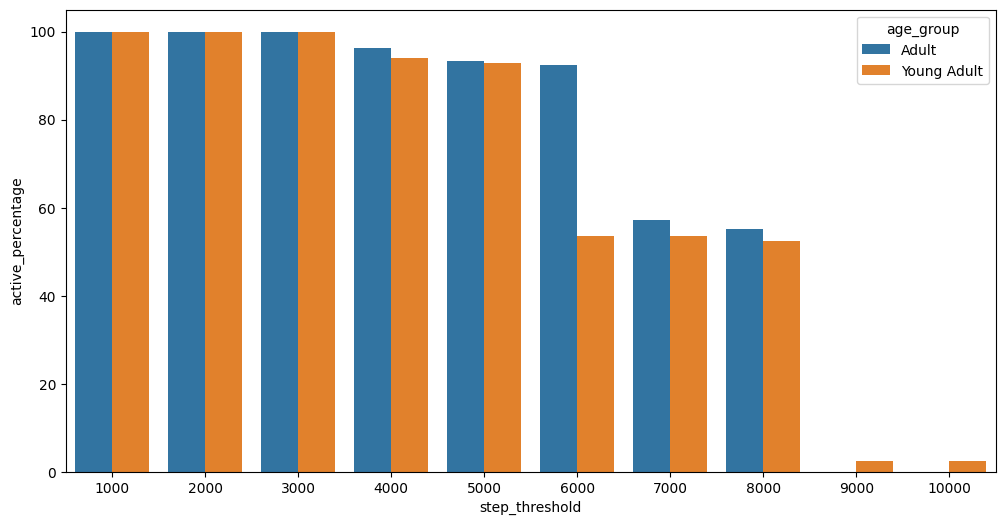

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

#Umstrukturieren Gruppenbalken
df_sleep_health_lifestyle_male_melted = df_sleep_health_lifestyle_male.melt(id_vars='age_group', var_name='step_threshold', value_name='active_percentage')

#Lesbare Achsenbeschriftung

df_sleep_health_lifestyle_male_melted['step_threshold'] = df_sleep_health_lifestyle_male_melted['step_threshold'].str.extract(r'(\d+)$')[0].astype(int)

#Sortieren nach Schrittanzahl
df_sleep_health_lifestyle_male_melted = df_sleep_health_lifestyle_male_melted.sort_values(by='step_threshold')

plt.figure(figsize=(12,6))
sns.barplot(data=df_sleep_health_lifestyle_male_melted, x='step_threshold', y='active_percentage', hue='age_group')

plt.show()

#Beide Geschlechter betrachten für Steps per Day -> Female and Male (nicht für Altersgruppe)

In [9]:
df_sleep_health_lifestyle_male_2 = pd.read_sql(sql=text('SELECT * FROM bmi_ageGroup_male'), con=engine)

In [10]:
df_sleep_health_lifestyle_male_2

,age_group,bmi_category,total_people,avg_physical_activity_level,avg_daily_steps
0,Adult,Normal Weight,62,76.24,7919.35
1,Adult,Obese,4,75.00,3600.00
2,Adult,Overweight,39,45.64,5882.05
3,Young Adult,Normal Weight,76,53.55,6815.79
4,Young Adult,Obese,5,38.00,3160.00
5,Young Adult,Overweight,3,40.67,5133.33


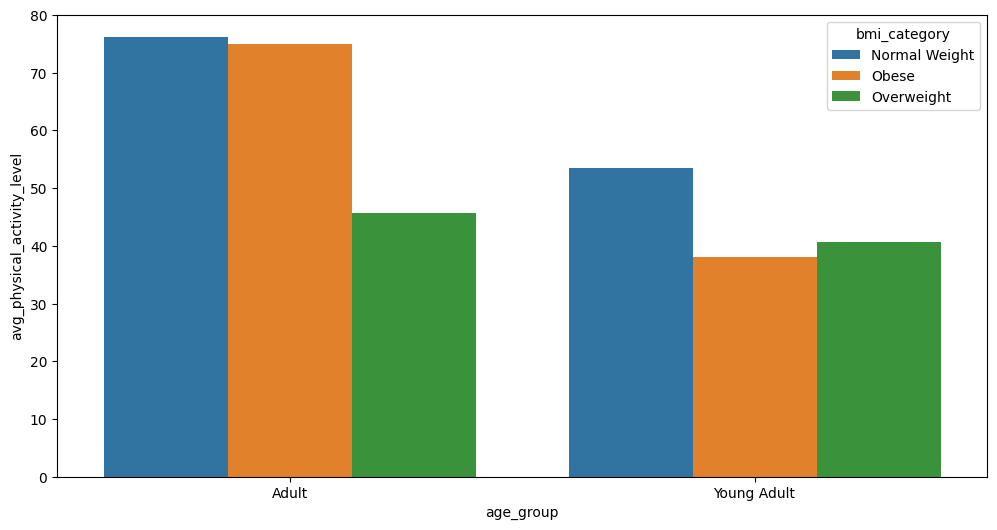

In [11]:
#Die Reihenfolge anpassen!

plt.figure(figsize=(12,6))
sns.barplot(data=df_sleep_health_lifestyle_male_2, x='age_group', y='avg_physical_activity_level', hue='bmi_category')

plt.show()

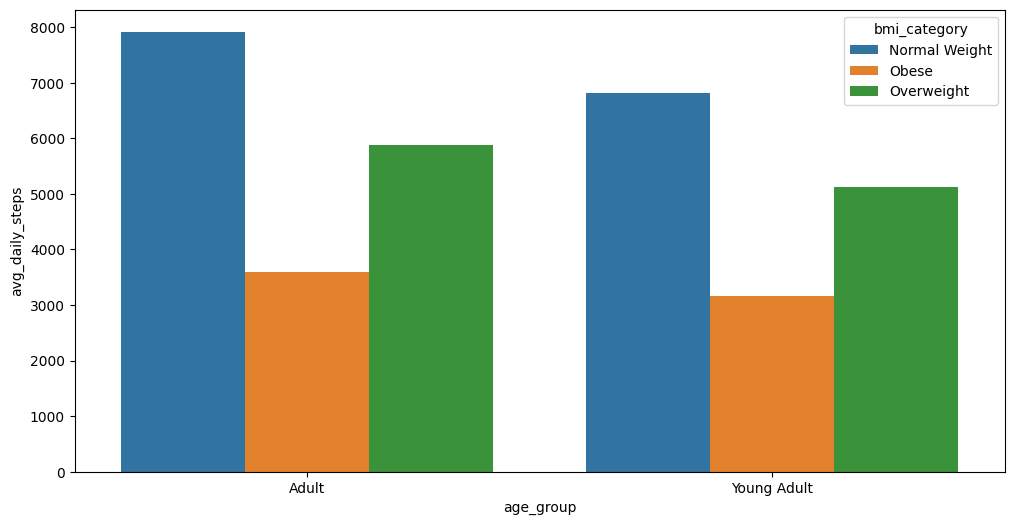

In [12]:
plt.figure(figsize=(12,6))
sns.barplot(data=df_sleep_health_lifestyle_male_2, x='age_group', y='avg_daily_steps', hue='bmi_category')

plt.show()

In [13]:
df_sleep_health_lifestyle_male_3 = pd.read_sql(sql=text('SELECT * FROM high_bp_ratio_male'), con=engine)

df_sleep_health_lifestyle_male_3

,age_group,occupation,persons_high_bp_ratio,avg_stress_level
0,Adult,Doctor,4,4.0
1,Young Adult,Sales Representative,2,8.0
2,Young Adult,Teacher,1,7.0
3,Young Adult,Software Engineer,1,8.0


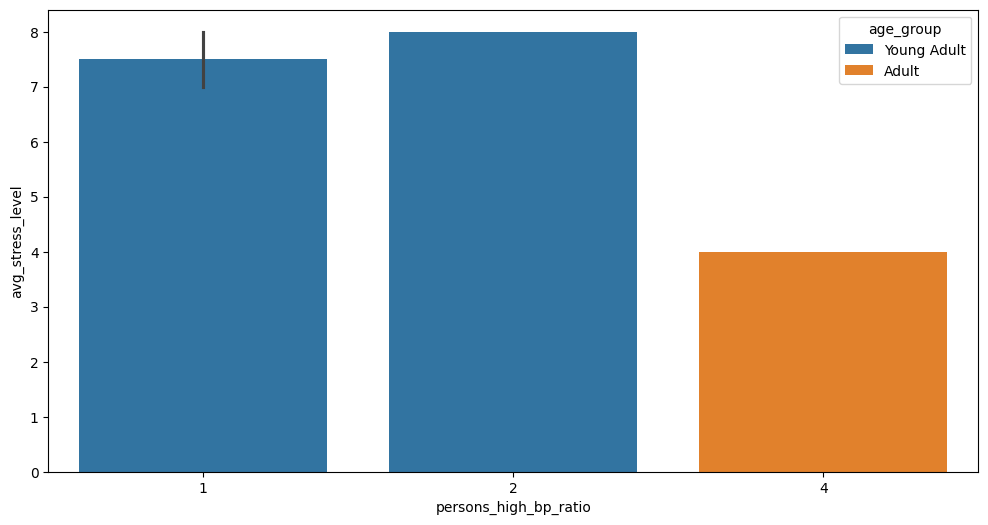

In [14]:
#Hier zeigt man den Stress Level mit hohem Blutdruck auf (gefiltert nach sys>=140 und dia>=90 in SQL ) -> hier würde ich gerne ncoh den Job aufzeigen
plt.figure(figsize=(12,6))
sns.barplot(data=df_sleep_health_lifestyle_male_3, x='persons_high_bp_ratio', y='avg_stress_level', hue='age_group')

plt.show()

In [15]:
df_sleep_health_lifestyle_male_4 = pd.read_sql(sql=text('SELECT * FROM sleep_health_lifestyle_male'), con=engine)
df_sleep_health_lifestyle_male_4


,gender,age_group,age,occupation,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,bmi_category,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,daily_steps,sleep_disorder
0,Male,Young Adult,27,Software Engineer,6.1,6,42,6,Overweight,126,83,77,4200,None
1,Male,Young Adult,28,Doctor,6.2,6,60,8,Normal Weight,125,80,75,10000,None
2,Male,Young Adult,28,Doctor,6.2,6,60,8,Normal Weight,125,80,75,10000,None
3,Male,Young Adult,28,Sales Representative,5.9,4,30,8,Obese,140,90,85,3000,Sleep Apnea
4,Male,Young Adult,28,Sales Representative,5.9,4,30,8,Obese,140,90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,Male,Adult,44,Salesperson,6.5,6,45,7,Overweight,130,85,72,6000,None
185,Male,Adult,48,Doctor,7.3,7,65,5,Obese,142,92,83,3500,Insomnia
186,Male,Adult,48,Doctor,7.3,7,65,5,Obese,142,92,83,3500,Insomnia
187,Male,Adult,49,Doctor,8.1,9,85,3,Obese,139,91,86,3700,Sleep Apnea


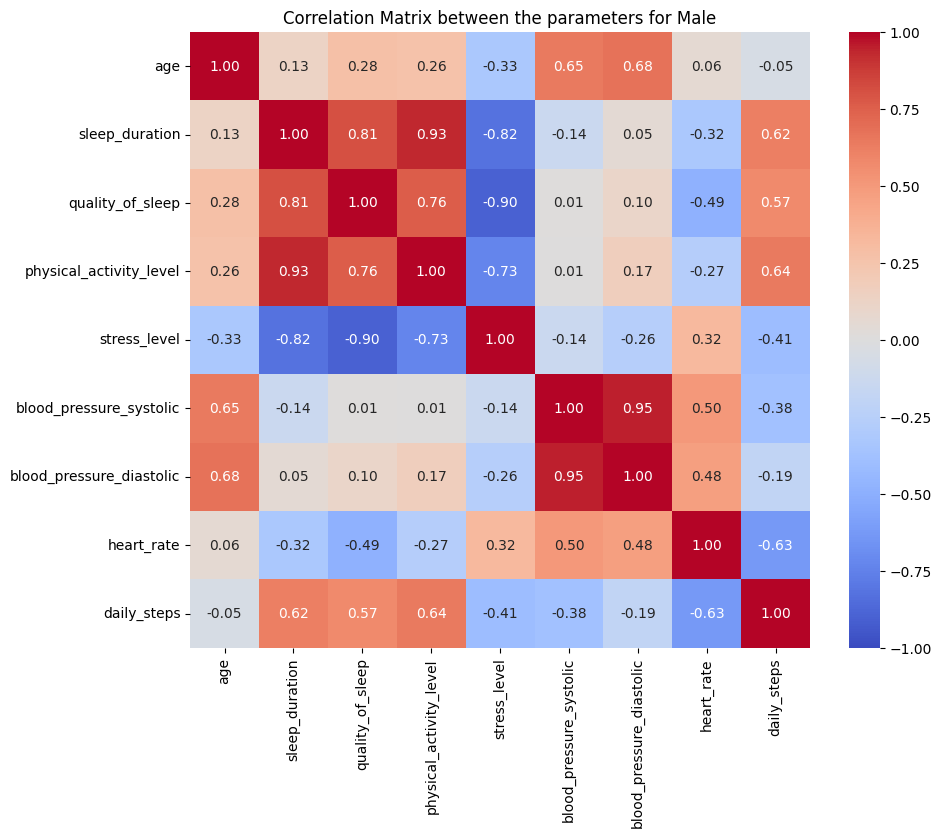

In [16]:
corr_matrix = df_sleep_health_lifestyle_male_4[['age', 'sleep_duration', 'quality_of_sleep', 'physical_activity_level', 'stress_level', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'heart_rate', 'daily_steps']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix between the parameters for Male')
plt.show()


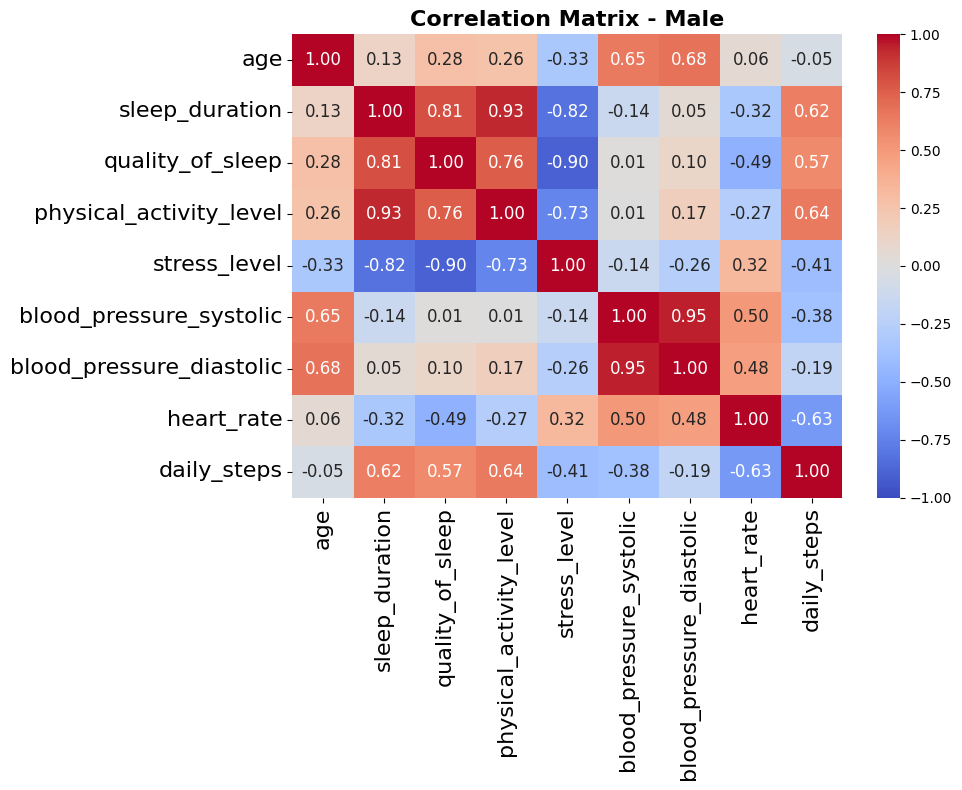

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df_sleep_health_lifestyle_male_4[[
    'age', 'sleep_duration', 'quality_of_sleep', 'physical_activity_level',
    'stress_level', 'blood_pressure_systolic', 'blood_pressure_diastolic',
    'heart_rate', 'daily_steps'
]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    vmin=-1, vmax=1,
    annot_kws={"size": 12}  # Größe der Zahlen im Heatmap
)

plt.title('Correlation Matrix - Male', fontsize=16, fontweight='bold')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()  # optional: passt das Layout automatisch an
plt.show()


In [18]:
df_sleep_health_lifestyle_female_4 = pd.read_sql(sql=text('SELECT * FROM sleep_health_lifestyle_female'), con=engine)
df_sleep_health_lifestyle_female_4

,gender,age_group,age,occupation,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,bmi_category,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,daily_steps,sleep_disorder
0,Female,Young Adult,29,Nurse,6.5,5,40,7,Normal Weight,132,87,80,4000,Sleep Apnea
1,Female,Young Adult,29,Nurse,6.5,5,40,7,Normal Weight,132,87,80,4000,Insomnia
2,Female,Young Adult,30,Nurse,6.4,5,35,7,Normal Weight,130,86,78,4100,Sleep Apnea
3,Female,Young Adult,30,Nurse,6.4,5,35,7,Normal Weight,130,86,78,4100,Insomnia
4,Female,Young Adult,31,Nurse,7.9,8,75,4,Normal Weight,117,76,69,6800,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,Female,Senior,59,Nurse,8.1,9,75,3,Overweight,140,95,68,7000,Sleep Apnea
181,Female,Senior,59,Nurse,8.0,9,75,3,Overweight,140,95,68,7000,Sleep Apnea
182,Female,Senior,59,Nurse,8.1,9,75,3,Overweight,140,95,68,7000,Sleep Apnea
183,Female,Senior,59,Nurse,8.1,9,75,3,Overweight,140,95,68,7000,Sleep Apnea


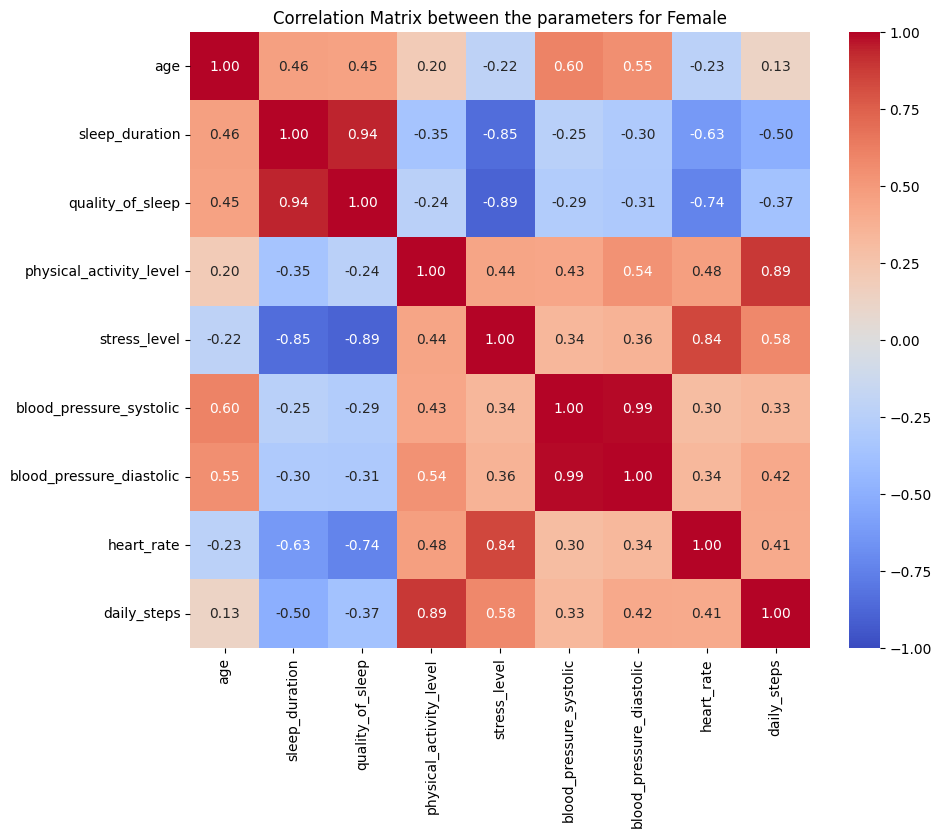

In [19]:
corr_matrix = df_sleep_health_lifestyle_female_4[['age', 'sleep_duration', 'quality_of_sleep', 'physical_activity_level', 'stress_level', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'heart_rate', 'daily_steps']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix between the parameters for Female')
plt.show()

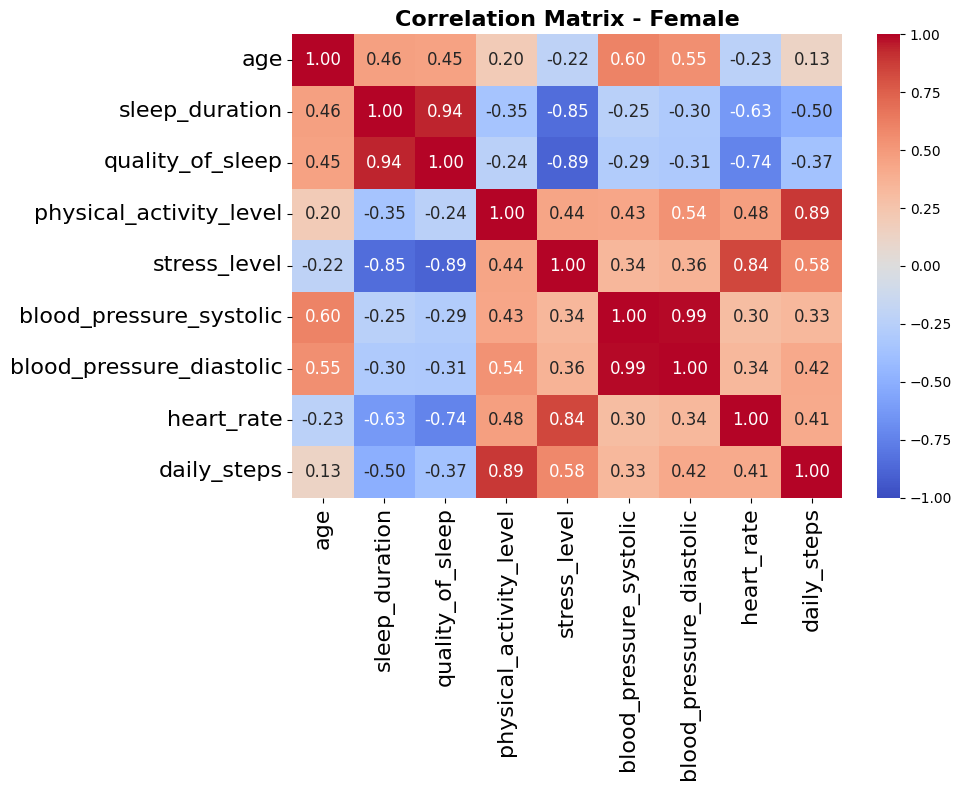

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df_sleep_health_lifestyle_female_4[[
    'age', 'sleep_duration', 'quality_of_sleep', 'physical_activity_level',
    'stress_level', 'blood_pressure_systolic', 'blood_pressure_diastolic',
    'heart_rate', 'daily_steps'
]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    vmin=-1, vmax=1,
    annot_kws={"size": 12}  # Größe der Zahlen im Heatmap
)

plt.title('Correlation Matrix - Female', fontsize=16, fontweight='bold')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()  # optional: passt das Layout automatisch an
plt.show()

In [21]:
#Das könnten wir kombinieren?
df_sleep_health_lifestyle_male_5 = pd.read_sql(sql=text('SELECT * FROM sleep_health_lifestyle_male'), con=engine)
df_sleep_health_lifestyle_male_5.groupby('sleep_disorder')['occupation'].value_counts()

sleep_disorder  occupation          
Insomnia        Salesperson             29
                Engineer                 4
                Doctor                   3
                Lawyer                   2
                Teacher                  2
                Software Engineer        1
Sleep Apnea     Doctor                   4
                Lawyer                   2
                Sales Representative     2
                Engineer                 1
                Salesperson              1
                Teacher                  1
Name: count, dtype: int64

In [22]:
df_sleep_health_lifestyle_female_5 = pd.read_sql(sql=text('SELECT * FROM sleep_health_lifestyle_female'), con=engine)
df_sleep_health_lifestyle_female_5.groupby('sleep_disorder')['occupation'].value_counts()

sleep_disorder  occupation
Insomnia        Teacher       25
                Accountant     7
                Nurse          3
                Engineer       1
Sleep Apnea     Nurse         61
                Teacher        3
                Scientist      2
                Lawyer         1
Name: count, dtype: int64

In [23]:
df_sleep_health_lifestyle_male_5.groupby('sleep_disorder')['age_group'].value_counts()

sleep_disorder  age_group  
Insomnia        Adult          38
                Young Adult     3
Sleep Apnea     Adult           6
                Young Adult     5
Name: count, dtype: int64

In [24]:
df_sleep_health_lifestyle_female_5.groupby('sleep_disorder')['age_group'].value_counts()

sleep_disorder  age_group  
Insomnia        Adult          27
                Senior          7
                Young Adult     2
Sleep Apnea     Senior         33
                Adult          30
                Young Adult     4
Name: count, dtype: int64

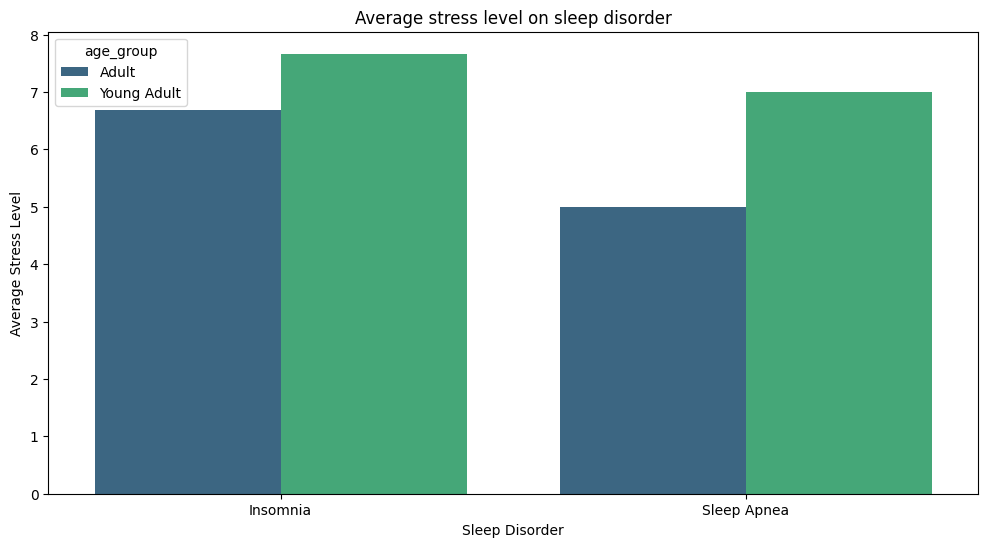

In [25]:
grouped = df_sleep_health_lifestyle_male_5.groupby(['sleep_disorder', 'age_group'])['stress_level'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=grouped, x='sleep_disorder', y='stress_level', hue='age_group', palette='viridis')
plt.title('Average stress level on sleep disorder')
plt.ylabel('Average Stress Level')
plt.xlabel('Sleep Disorder')
#plt.xticks(rotation=45)
plt.show()

# gibt es Unterschiede im Stress Level zwischen Altersgruppen bei gleicher Schlafstörung?
# Haben Männer mit Insomnie einen höheeren durchschnittlichen Stress Level als Männer ohne Schlafstörung?

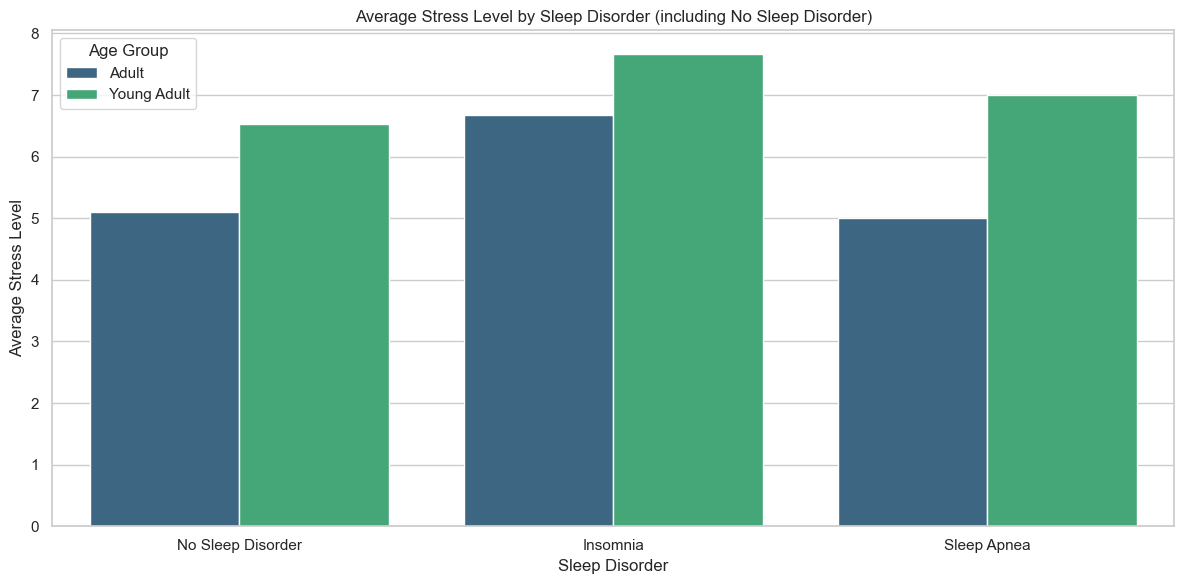

In [26]:
# Schritt 1: NaN-Werte in 'sleep_disorder' ersetzen
df_plot = df_sleep_health_lifestyle_male_5.copy()
df_plot['sleep_disorder'] = df_plot['sleep_disorder'].fillna('No Sleep Disorder')  # oder z.B. 'No Info'

order = ['No Sleep Disorder', 'Insomnia', 'Sleep Apnea']

# Schritt 2: Gruppieren
grouped = df_plot.groupby(['sleep_disorder', 'age_group'])['stress_level'].mean().reset_index()

# Schritt 3: Plotten
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.barplot(
    data=grouped,
    x='sleep_disorder',
    y='stress_level',
    hue='age_group',
    palette='viridis',
    order=order
)

plt.title('Average Stress Level by Sleep Disorder (including No Sleep Disorder)')
plt.ylabel('Average Stress Level')
plt.xlabel('Sleep Disorder')
plt.legend(title='Age Group')
plt.tight_layout()
plt.show()


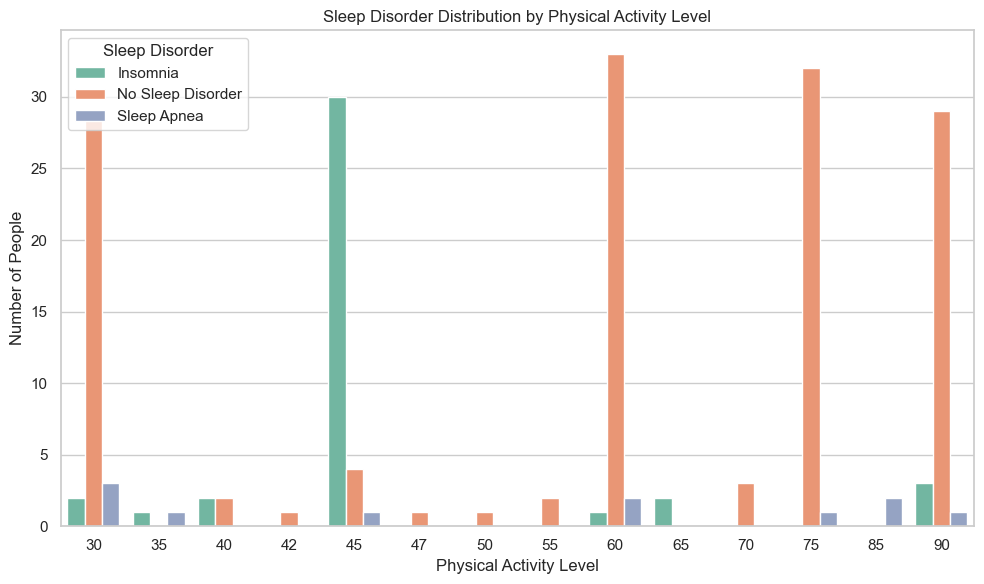

In [27]:
#NICHT AUSSAGEKRÄFTIG

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# NaN-Werte in sleep_disorder behandeln
df_plot = df_sleep_health_lifestyle_male_5.copy()
df_plot['sleep_disorder'] = df_plot['sleep_disorder'].fillna('No Sleep Disorder')

# Gruppieren: Anzahl Personen je Kombination
grouped = df_plot.groupby(['physical_activity_level', 'sleep_disorder']).size().reset_index(name='count')

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=grouped,
    x='physical_activity_level',
    y='count',
    hue='sleep_disorder',
    palette='Set2'
)
plt.title('Sleep Disorder Distribution by Physical Activity Level')
plt.xlabel('Physical Activity Level')
plt.ylabel('Number of People')
plt.legend(title='Sleep Disorder')
plt.tight_layout()
plt.show()


In [28]:
#mit dem gesamten Datensatz: Wie unterscheiden sich Schlafstörungen nach Beruf?

In [29]:
#Hypothese 1: Höherer Stress -> schlechtere Schlafqualität und kürzere Schlafdauer

#Hypothese 2:  Ältere Menschen schlafen kürzer, aber berichten bessere Qualität

<Axes: xlabel='age_group', ylabel='sleep_duration'>

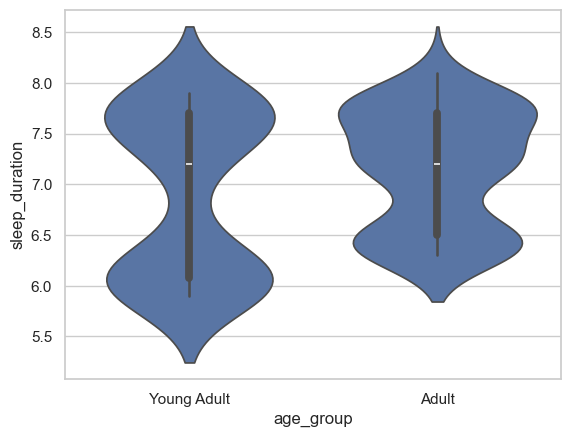

In [30]:
#sns.violinplot(data=df_sleep_health_lifestyle_male_5, x='age_group', y='sleep_duration', inner='quartile', palette='muted')
sns.violinplot(data=df_sleep_health_lifestyle_male_5, x='age_group', y='sleep_duration')


<Axes: xlabel='occupation'>

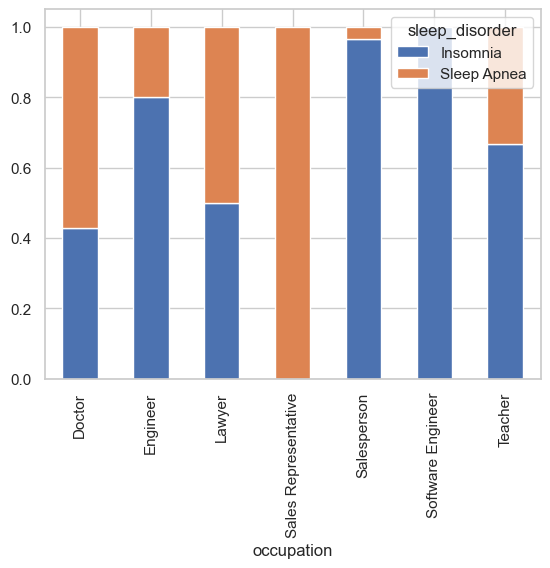

In [31]:
#only male -> in this case: combined - female and male to be considered
pd.crosstab(df_sleep_health_lifestyle_male_5['occupation'], df_sleep_health_lifestyle_male_5['sleep_disorder'], normalize='index').plot(kind='bar', stacked=True)

<Axes: xlabel='occupation'>

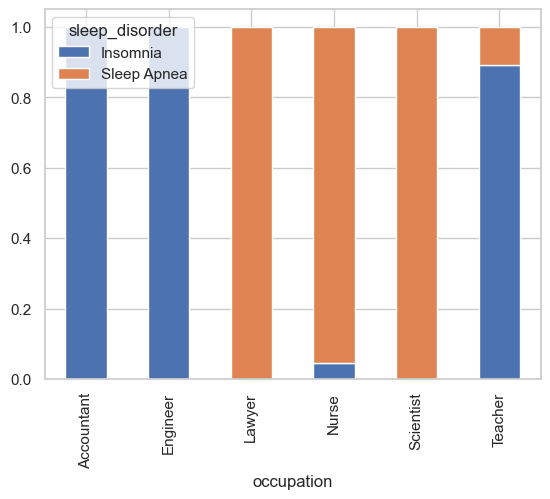

In [32]:
pd.crosstab(df_sleep_health_lifestyle_female_5['occupation'], df_sleep_health_lifestyle_female_5['sleep_disorder'], normalize='index').plot(kind='bar', stacked=True)

In [33]:
### Let's create a dataframe out of that
df_sleep_health_lifestyle = pd.read_sql(sql=text('SELECT * FROM sleep_health_lifestyle'), con=engine)

In [34]:
df_sleep_health_lifestyle

,gender,age_group,age,occupation,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,bmi_category,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,daily_steps,sleep_disorder
0,Female,Young Adult,29,Nurse,6.5,5,40,7,Normal Weight,132,87,80,4000,Sleep Apnea
1,Female,Young Adult,29,Nurse,6.5,5,40,7,Normal Weight,132,87,80,4000,Insomnia
2,Female,Young Adult,30,Nurse,6.4,5,35,7,Normal Weight,130,86,78,4100,Sleep Apnea
3,Female,Young Adult,30,Nurse,6.4,5,35,7,Normal Weight,130,86,78,4100,Insomnia
4,Female,Young Adult,31,Nurse,7.9,8,75,4,Normal Weight,117,76,69,6800,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,Male,Adult,44,Salesperson,6.5,6,45,7,Overweight,130,85,72,6000,None
370,Male,Adult,48,Doctor,7.3,7,65,5,Obese,142,92,83,3500,Insomnia
371,Male,Adult,48,Doctor,7.3,7,65,5,Obese,142,92,83,3500,Insomnia
372,Male,Adult,49,Doctor,8.1,9,85,3,Obese,139,91,86,3700,Sleep Apnea


In [35]:
df_sleep_health_lifestyle.describe()


,age,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,daily_steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,42.184492,7.132086,7.312834,59.171123,5.385027,128.553476,84.649733,70.165775,6816.844920
std,8.673133,0.795657,1.196956,20.830804,1.774526,7.748118,6.161611,4.135676,1617.915679
min,27.000000,5.800000,4.000000,30.000000,3.000000,115.000000,75.000000,65.000000,3000.000000
25%,35.250000,6.400000,6.000000,45.000000,4.000000,125.000000,80.000000,68.000000,5600.000000
50%,43.000000,7.200000,7.000000,60.000000,5.000000,130.000000,85.000000,70.000000,7000.000000
75%,50.000000,7.800000,8.000000,75.000000,7.000000,135.000000,90.000000,72.000000,8000.000000
max,59.000000,8.500000,9.000000,90.000000,8.000000,142.000000,95.000000,86.000000,10000.000000


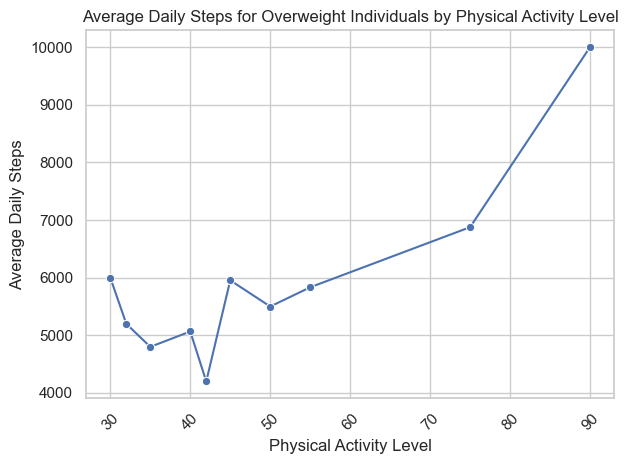

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Nur "Overweight"-Einträge filtern
df_overweight = df_sleep_health_lifestyle[df_sleep_health_lifestyle['bmi_category'] == 'Overweight']

# Durchschnittliche Schritte nach Aktivitätslevel berechnen
avg_steps_overweight = df_overweight.groupby('physical_activity_level')['daily_steps'].mean().reset_index()

# Nach Aktivitätslevel sortieren (optional, für bessere Linienführung)
avg_steps_overweight = avg_steps_overweight.sort_values('physical_activity_level')

# Liniendiagramm zeichnen
sns.lineplot(data=avg_steps_overweight, x='physical_activity_level', y='daily_steps', marker='o')
plt.title('Average Daily Steps for Overweight Individuals by Physical Activity Level')
plt.xlabel('Physical Activity Level')
plt.ylabel('Average Daily Steps')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


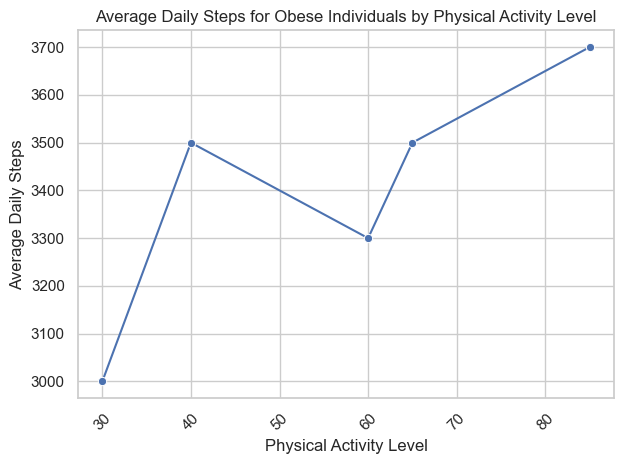

In [37]:
# Nur "Obese"-Einträge filtern
df_overweight = df_sleep_health_lifestyle[df_sleep_health_lifestyle['bmi_category'] == 'Obese']

# Durchschnittliche Schritte nach Aktivitätslevel berechnen
avg_steps_overweight = df_overweight.groupby('physical_activity_level')['daily_steps'].mean().reset_index()

# Nach Aktivitätslevel sortieren (optional, für bessere Linienführung)
avg_steps_overweight = avg_steps_overweight.sort_values('physical_activity_level')

# Liniendiagramm zeichnen
sns.lineplot(data=avg_steps_overweight, x='physical_activity_level', y='daily_steps', marker='o')
plt.title('Average Daily Steps for Obese Individuals by Physical Activity Level')
plt.xlabel('Physical Activity Level')
plt.ylabel('Average Daily Steps')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
### Let's create a dataframe out of that
df_kpi4 = pd.read_sql(sql=text('SELECT * FROM stress_hypertensionRate_occupation_over_30_persons'), con=engine)
df_kpi4

,occupation,age_group,gender,num_persons,avg_stress_level,avg_bp_systolic,avg_bp_diastolic,hypertension_rate
0,Doctor,Young Adult,Male,65,7.015385,122.076923,80.000000,0.000000
1,Lawyer,Adult,Male,44,5.045455,129.772727,84.863636,0.000000
2,Nurse,Senior,Female,37,3.540541,139.594595,94.648649,0.972973
3,Teacher,Adult,Female,35,4.285714,131.285714,87.142857,0.771429
4,Salesperson,Adult,Male,32,7.000000,130.000000,85.000000,0.000000
5,Engineer,Senior,Female,31,3.000000,125.000000,80.000000,0.000000
6,Nurse,Adult,Female,31,7.806452,138.903226,94.129032,0.935484


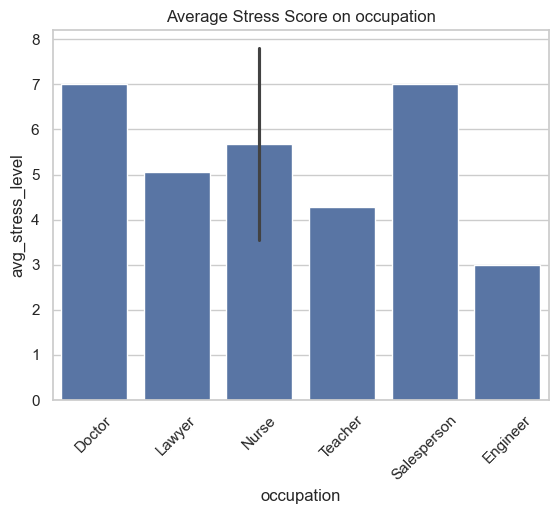

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=df_kpi4, x='occupation', y='avg_stress_level')
plt.xticks(rotation=45)
plt.title("Average Stress Score on occupation")
plt.show()


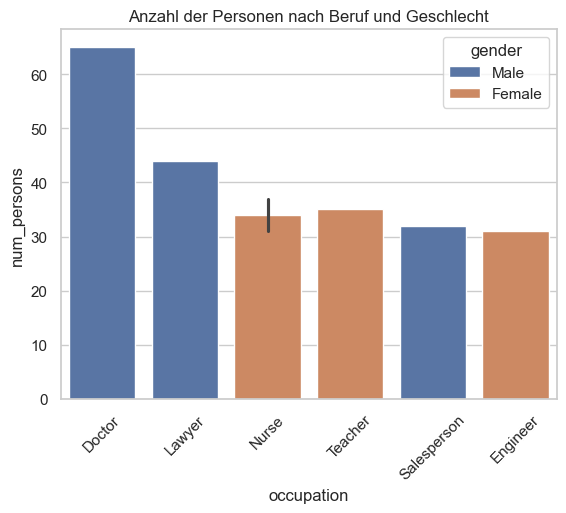

In [40]:
sns.barplot(data=df_kpi4, x='occupation', y='num_persons', hue='gender')
plt.xticks(rotation=45)
plt.title("Anzahl der Personen nach Beruf und Geschlecht")
plt.show()


In [41]:
#Research Question 2
df_kpi2 = pd.read_sql(sql=text('SELECT * FROM active_sedentary_jobs_sleep_score'), con=engine)
df_kpi2

,job_type,occupation,gender,num_persons,avg_quality_of_sleep,avg_sleep_duration
0,Sedentary,Salesperson,Male,32,6.000000,6.403125
1,Active,Nurse,Female,73,7.369863,7.063014
2,Active,Teacher,Female,35,7.114286,6.705714
3,Sedentary,Accountant,Female,36,7.888889,7.111111
4,Active,Engineer,Female,32,9.000000,8.425000
5,Sedentary,Lawyer,Male,45,7.933333,7.422222
6,Active,Engineer,Male,31,7.806452,7.535484
7,Active,Doctor,Male,69,6.579710,6.934783


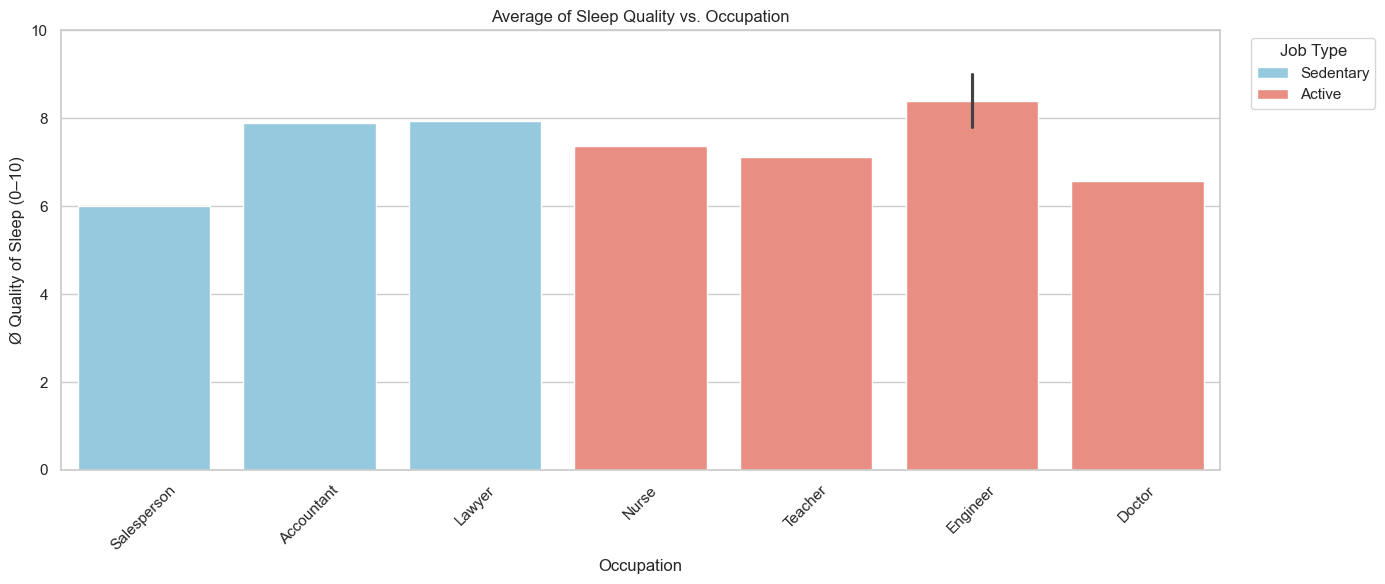

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

job_type_colors = {
    "Sedentary": "skyblue",
    "Active": "salmon"
}

# Schritt 1: Occupations nach job_type sortieren
sedentary_occupations = df_kpi2[df_kpi2['job_type'] == 'Sedentary']['occupation'].unique()
active_occupations = df_kpi2[df_kpi2['job_type'] == 'Active']['occupation'].unique()

# Kombinierte Reihenfolge
ordered_occupations = list(sedentary_occupations) + list(active_occupations)

# Schritt 2: Figure mit angepasster Größe erstellen
plt.figure(figsize=(14, 6))  # Breiter für mehr Platz rechts

# Barplot mit benutzerdefinierter Ordnung
sns.barplot(
    data=df_kpi2,
    x='occupation',
    y='avg_quality_of_sleep',
    hue='job_type',
    palette=job_type_colors,
    order=ordered_occupations
)

plt.title('Average of Sleep Quality vs. Occupation')
plt.ylabel('Ø Quality of Sleep (0–10)')
plt.xlabel('Occupation')
plt.xticks(rotation=45)
plt.ylim(0, 10)

# Legende außerhalb des Plots rechts oben platzieren
plt.legend(title='Job Type', loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()



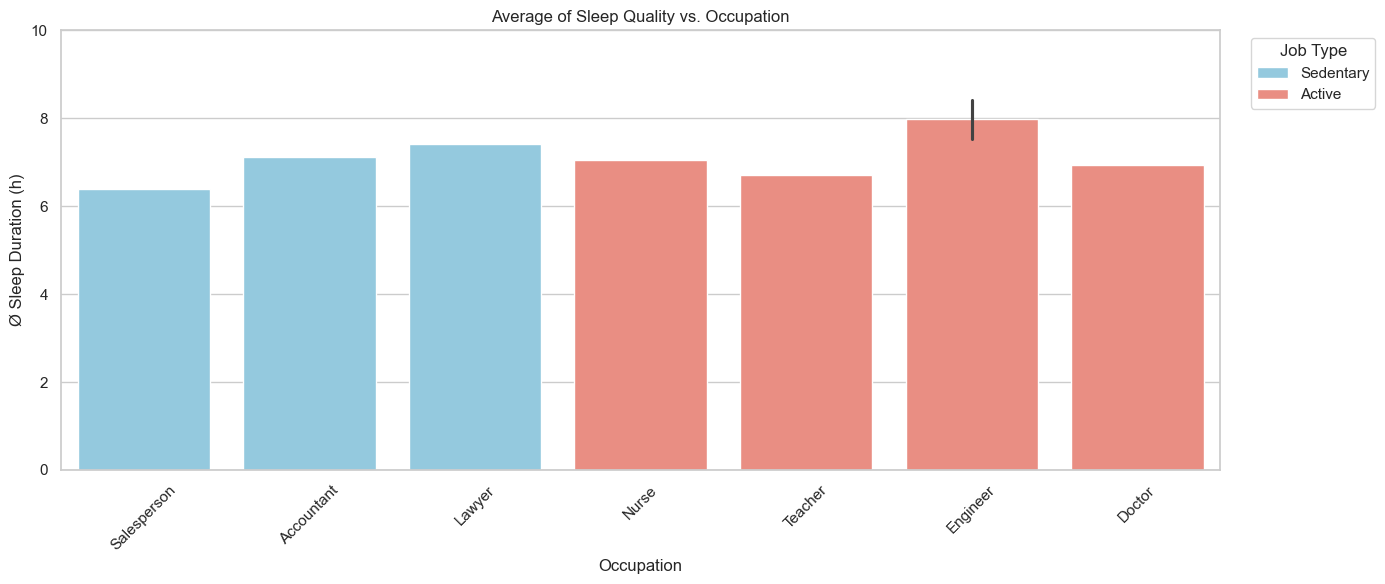

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

job_type_colors = {
    "Sedentary": "skyblue",
    "Active": "salmon"
}

# Schritt 1: Occupations nach job_type sortieren
sedentary_occupations = df_kpi2[df_kpi2['job_type'] == 'Sedentary']['occupation'].unique()
active_occupations = df_kpi2[df_kpi2['job_type'] == 'Active']['occupation'].unique()

# Kombinierte Reihenfolge
ordered_occupations = list(sedentary_occupations) + list(active_occupations)

# Schritt 2: Figure mit angepasster Größe erstellen
plt.figure(figsize=(14, 6))  # Breiter für mehr Platz rechts

# Barplot mit benutzerdefinierter Ordnung
sns.barplot(
    data=df_kpi2,
    x='occupation',
    y='avg_sleep_duration',
    hue='job_type',
    palette=job_type_colors,
    order=ordered_occupations
)

plt.title('Average of Sleep Quality vs. Occupation')
plt.ylabel('Ø Sleep Duration (h)')
plt.xlabel('Occupation')
plt.xticks(rotation=45)
plt.ylim(0, 10)

# Legende außerhalb des Plots rechts oben platzieren
plt.legend(title='Job Type', loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()


In [44]:
#Research Question 2
df_kpi2_test = pd.read_sql(sql=text('SELECT * FROM sleep_stress_occupation_without_gender'), con=engine)
df_kpi2_test

,job_type,occupation,num_persons,avg_quality_of_sleep,avg_sleep_duration,avg_stress_level
0,Active,Engineer,63,8.412698,7.987302,3.888889
1,Sedentary,Accountant,37,7.891892,7.113514,4.594595
2,Active,Doctor,71,6.647887,6.970423,6.732394
3,Active,Nurse,73,7.369863,7.063014,5.547945
4,Active,Teacher,40,6.975000,6.690000,4.525000
5,Sedentary,Salesperson,32,6.000000,6.403125,7.000000
6,Sedentary,Lawyer,47,7.893617,7.410638,5.063830


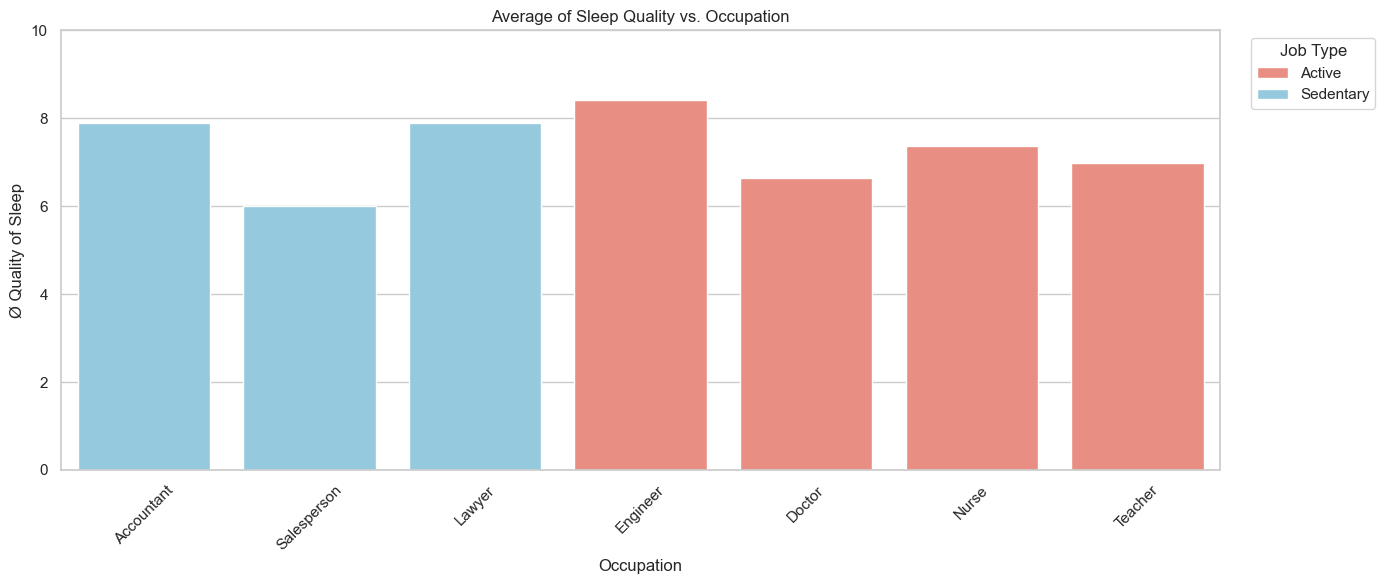

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

job_type_colors = {
    "Sedentary": "skyblue",
    "Active": "salmon"
}

# Schritt 1: Occupations nach job_type sortieren
sedentary_occupations = df_kpi2_test[df_kpi2_test['job_type'] == 'Sedentary']['occupation'].unique()
active_occupations = df_kpi2_test[df_kpi2_test['job_type'] == 'Active']['occupation'].unique()

# Kombinierte Reihenfolge
ordered_occupations = list(sedentary_occupations) + list(active_occupations)

# Schritt 2: Figure mit angepasster Größe erstellen
plt.figure(figsize=(14, 6))  # Breiter für mehr Platz rechts

# Barplot mit benutzerdefinierter Ordnung
sns.barplot(
    data=df_kpi2_test,
    x='occupation',
    y='avg_quality_of_sleep',
    hue='job_type',
    palette=job_type_colors,
    order=ordered_occupations
)

plt.title('Average of Sleep Quality vs. Occupation')
plt.ylabel('Ø Quality of Sleep')
plt.xlabel('Occupation')
plt.xticks(rotation=45)
plt.ylim(0, 10)

# Legende außerhalb des Plots rechts oben platzieren
plt.legend(title='Job Type', loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

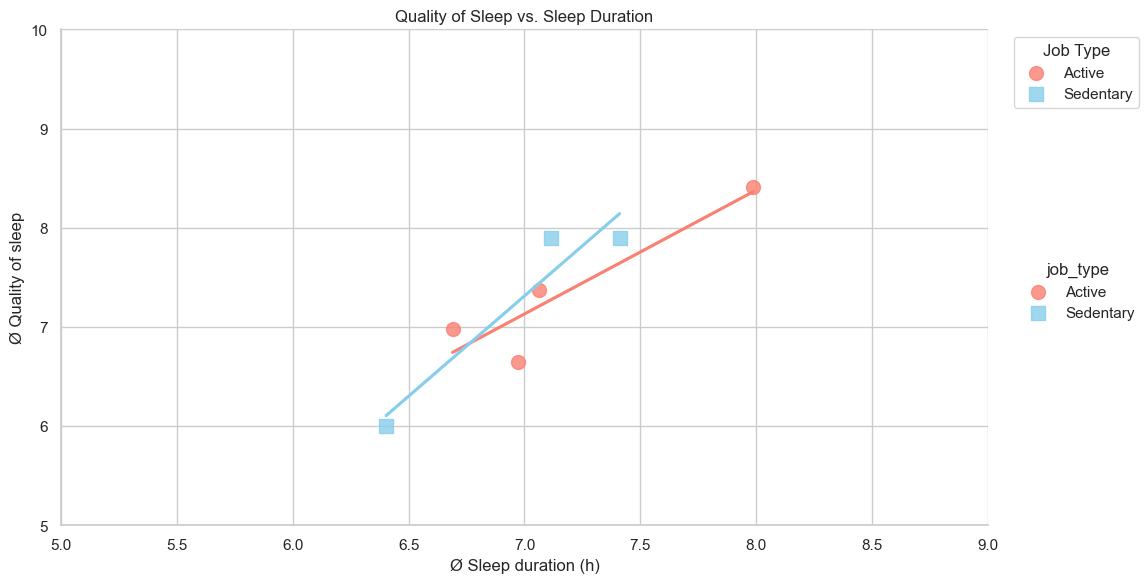

In [46]:
job_type_colors = {
    "Sedentary": "skyblue",
    "Active": "salmon"
}

sns.lmplot(
    data=df_kpi2_test,
    x='avg_sleep_duration',
    y='avg_quality_of_sleep',
    palette=job_type_colors,
    hue='job_type',       # trennt nach job_type
    height=6,             # Höhe des Plots
    aspect=1.5,           # Breite = Höhe * aspect
    markers=['o', 's'],   # unterschiedliche Marker für job_type (optional)
    scatter_kws={'s':100}, # Punktgröße
    ci=None
)

plt.title('Quality of Sleep vs. Sleep Duration')
plt.xlabel('Ø Sleep duration (h)')
plt.ylabel('Ø Quality of sleep')
plt.xlim(5, 9)
plt.ylim(5, 10)
plt.grid(True)
plt.tight_layout()

# Legende außerhalb des Plots rechts oben platzieren
plt.legend(title='Job Type', loc='upper left', bbox_to_anchor=(1.02, 1))

plt.show()


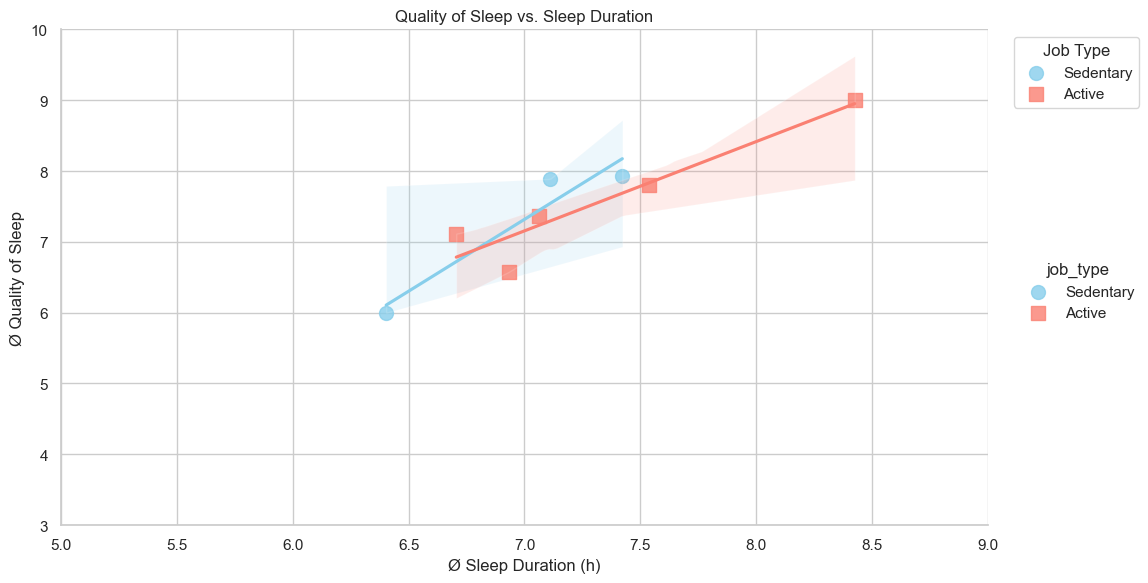

In [47]:
job_type_colors = {
    "Sedentary": "skyblue",
    "Active": "salmon"
}

sns.lmplot(
    data=df_kpi2,
    x='avg_sleep_duration',
    y='avg_quality_of_sleep',
    palette=job_type_colors,
    hue='job_type',       # trennt nach job_type
    height=6,             # Höhe des Plots
    aspect=1.5,           # Breite = Höhe * aspect
    markers=['o', 's'],   # unterschiedliche Marker für job_type (optional)
    scatter_kws={'s':100} # Punktgröße
    #ci=95 #stellt sicher, dass der 95 % Konfidenzintervall gezeichnet wird, Bereich, in dem mit 95%iger Wahrscheinlichkeit die wahre Regressionslinie liegt (für jede Gruppe von job_type)
)

plt.title('Quality of Sleep vs. Sleep Duration')
plt.xlabel('Ø Sleep Duration (h)')
plt.ylabel('Ø Quality of Sleep')
plt.xlim(5, 9)
plt.ylim(3, 10)
plt.grid(True)
plt.tight_layout()

# Legende außerhalb des Plots rechts oben platzieren
plt.legend(title='Job Type', loc='upper left', bbox_to_anchor=(1.02, 1))

plt.show()

In [48]:
df_kpi2_new = pd.read_sql(sql=text('SELECT * FROM active_sedentary_jobs_sleep_score_onlyGender'), con=engine)
df_kpi2_new

,job_type,occupation,gender,num_persons,avg_quality_of_sleep,avg_sleep_duration
0,Active,Doctor,Female,2,9.000000,8.200000
1,Active,Teacher,Female,35,7.114286,6.705714
2,Active,Engineer,Female,32,9.000000,8.425000
3,Active,Nurse,Female,73,7.369863,7.063014
4,Sedentary,Manager,Female,1,7.000000,6.900000
5,Sedentary,Scientist,Female,4,5.000000,6.000000
6,Sedentary,Lawyer,Female,2,7.000000,7.150000
7,Sedentary,Accountant,Female,36,7.888889,7.111111
8,Active,Teacher,Male,5,6.000000,6.580000
9,Active,Engineer,Male,31,7.806452,7.535484


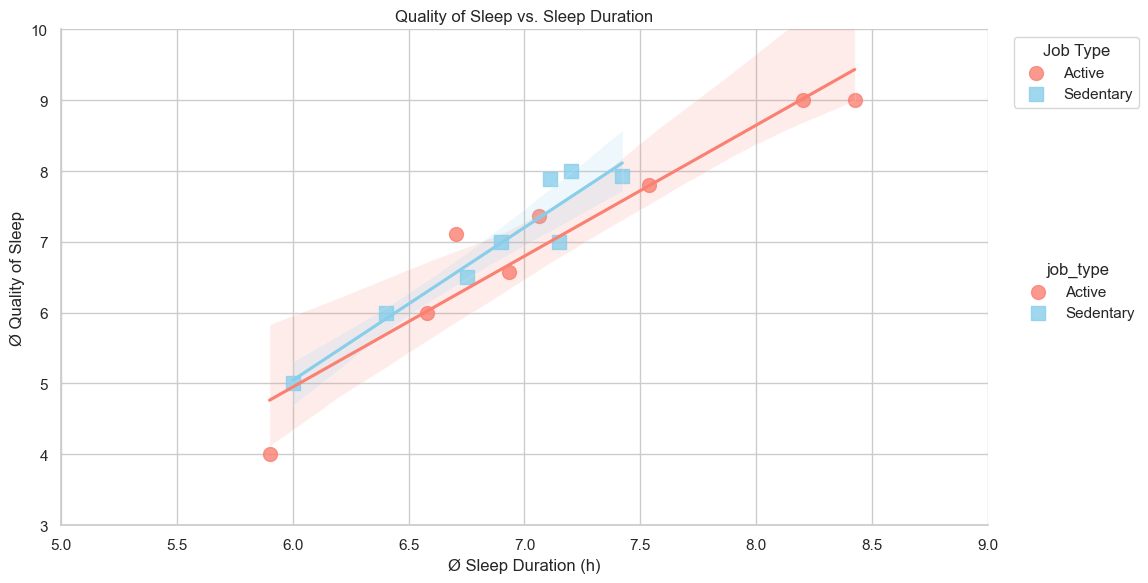

In [49]:
job_type_colors = {
    "Sedentary": "skyblue",
    "Active": "salmon"
}

sns.lmplot(
    data=df_kpi2_new,
    x='avg_sleep_duration',
    y='avg_quality_of_sleep',
    palette=job_type_colors,
    hue='job_type',       # trennt nach job_type
    height=6,             # Höhe des Plots
    aspect=1.5,           # Breite = Höhe * aspect
    markers=['o', 's'],   # unterschiedliche Marker für job_type (optional)
    scatter_kws={'s':100} # Punktgröße
    #ci=95 #stellt sicher, dass der 95 % Konfidenzintervall gezeichnet wird, Bereich, in dem mit 95%iger Wahrscheinlichkeit die wahre Regressionslinie liegt (für jede Gruppe von job_type)
)

plt.title('Quality of Sleep vs. Sleep Duration')
plt.xlabel('Ø Sleep Duration (h)')
plt.ylabel('Ø Quality of Sleep')
plt.xlim(5, 9)
plt.ylim(3, 10)
plt.grid(True)
plt.tight_layout()

# Legende außerhalb des Plots rechts oben platzieren
plt.legend(title='Job Type', loc='upper left', bbox_to_anchor=(1.02, 1))

plt.show()

In [50]:
df_kpi2_new2 = pd.read_sql(sql=text('SELECT * FROM sleep_stress_occupation'), con=engine)
df_kpi2_new2

,job_type,occupation,gender,num_persons,avg_quality_of_sleep,avg_sleep_duration,avg_stress_level
0,Sedentary,Salesperson,Male,32,6.000000,6.403125,7.000000
1,Active,Nurse,Female,73,7.369863,7.063014,5.547945
2,Active,Teacher,Female,35,7.114286,6.705714,4.285714
3,Sedentary,Accountant,Female,36,7.888889,7.111111,4.555556
4,Active,Engineer,Female,32,9.000000,8.425000,3.000000
5,Sedentary,Lawyer,Male,45,7.933333,7.422222,5.044444
6,Active,Engineer,Male,31,7.806452,7.535484,4.806452
7,Active,Doctor,Male,69,6.579710,6.934783,6.840580


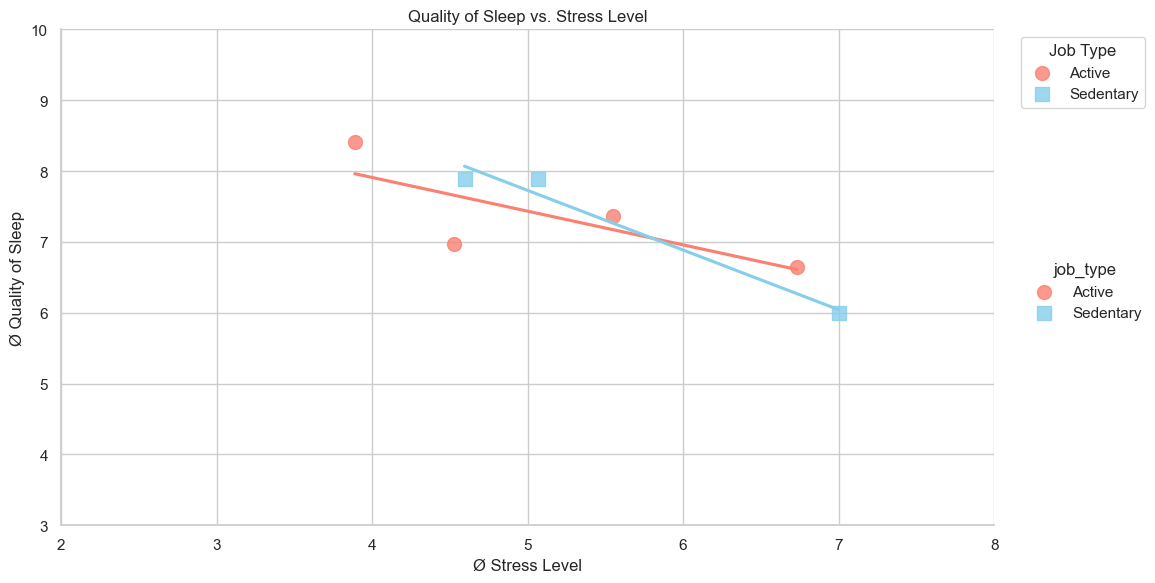

In [51]:
job_type_colors = {
    "Sedentary": "skyblue",
    "Active": "salmon"
}

sns.lmplot(
    data=df_kpi2_test,
    x='avg_stress_level',
    y='avg_quality_of_sleep',
    palette=job_type_colors,
    hue='job_type',       # trennt nach job_type
    height=6,             # Höhe des Plots
    aspect=1.5,           # Breite = Höhe * aspect
    markers=['o', 's'],   # unterschiedliche Marker für job_type (optional)
    scatter_kws={'s':100},
    ci=None # Punktgröße
    #ci=95 #stellt sicher, dass der 95 % Konfidenzintervall gezeichnet wird, Bereich, in dem mit 95%iger Wahrscheinlichkeit die wahre Regressionslinie liegt (für jede Gruppe von job_type)
)

plt.title('Quality of Sleep vs. Stress Level')
plt.xlabel('Ø Stress Level')
plt.ylabel('Ø Quality of Sleep')
plt.xlim(2, 8)
plt.ylim(3, 10)
plt.grid(True)
plt.tight_layout()

# Legende außerhalb des Plots rechts oben platzieren
plt.legend(title='Job Type', loc='upper left', bbox_to_anchor=(1.02, 1))

plt.show()

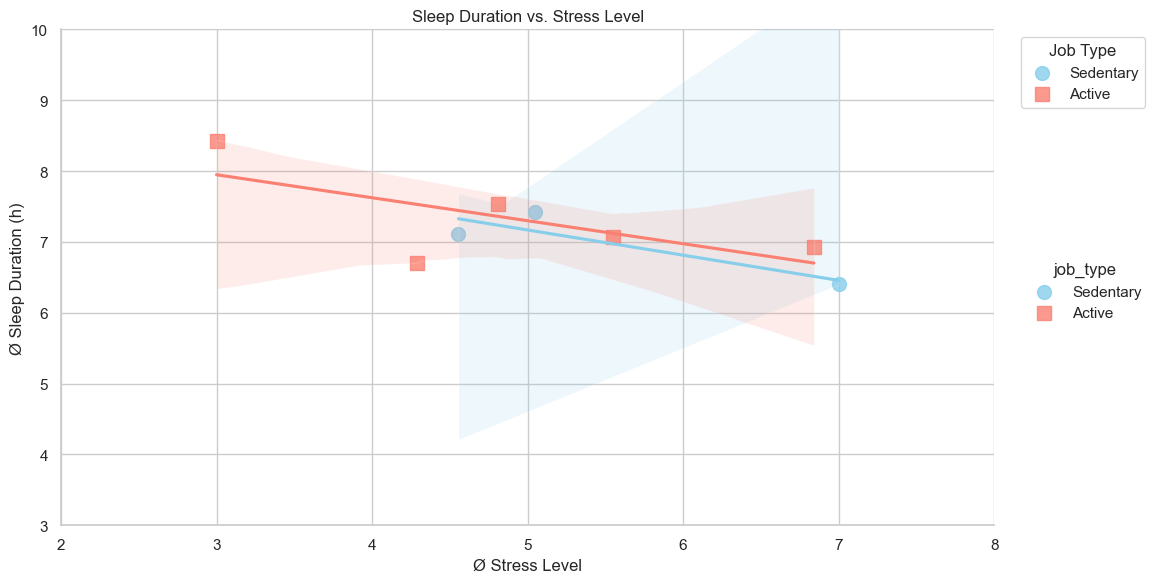

In [52]:
job_type_colors = {
    "Sedentary": "skyblue",
    "Active": "salmon"
}

sns.lmplot(
    data=df_kpi2_new2,
    x='avg_stress_level',
    y='avg_sleep_duration',
    palette=job_type_colors,
    hue='job_type',       # trennt nach job_type
    height=6,             # Höhe des Plots
    aspect=1.5,           # Breite = Höhe * aspect
    markers=['o', 's'],   # unterschiedliche Marker für job_type (optional)
    scatter_kws={'s':100} # Punktgröße
    #ci=95 #stellt sicher, dass der 95 % Konfidenzintervall gezeichnet wird, Bereich, in dem mit 95%iger Wahrscheinlichkeit die wahre Regressionslinie liegt (für jede Gruppe von job_type)
)

plt.title('Sleep Duration vs. Stress Level')
plt.xlabel('Ø Stress Level')
plt.ylabel('Ø Sleep Duration (h)')
plt.xlim(2, 8)
plt.ylim(3, 10)
plt.grid(True)
plt.tight_layout()

# Legende außerhalb des Plots rechts oben platzieren
plt.legend(title='Job Type', loc='upper left', bbox_to_anchor=(1.02, 1))

plt.show()

In [53]:
df_kpi4_new = pd.read_sql(sql=text('SELECT * FROM stress_hypertensionRate_occupation_over_20_persons_onlyGender'), con=engine)
df_kpi4_new

,occupation,gender,num_persons,avg_stress_level,avg_bp_systolic,avg_bp_diastolic,hypertension_rate
0,Nurse,Female,73,5.547945,138.520548,93.726027,0.890411
1,Doctor,Male,69,6.840580,123.144928,80.666667,0.057971
2,Lawyer,Male,45,5.044444,129.888889,84.933333,0.000000
3,Accountant,Female,36,4.555556,117.722222,76.944444,0.000000
4,Teacher,Female,35,4.285714,131.285714,87.142857,0.771429
5,Engineer,Female,32,3.000000,125.000000,80.000000,0.000000
6,Salesperson,Male,32,7.000000,130.000000,85.000000,0.000000
7,Engineer,Male,31,4.806452,126.838710,82.806452,0.000000


In [54]:
df_kpi4_new['hypertension_rate_percent'] = df_kpi4_new['hypertension_rate'] * 100
df_kpi4_new

,occupation,gender,num_persons,avg_stress_level,avg_bp_systolic,avg_bp_diastolic,hypertension_rate,hypertension_rate_percent
0,Nurse,Female,73,5.547945,138.520548,93.726027,0.890411,89.041096
1,Doctor,Male,69,6.840580,123.144928,80.666667,0.057971,5.797101
2,Lawyer,Male,45,5.044444,129.888889,84.933333,0.000000,0.000000
3,Accountant,Female,36,4.555556,117.722222,76.944444,0.000000,0.000000
4,Teacher,Female,35,4.285714,131.285714,87.142857,0.771429,77.142857
5,Engineer,Female,32,3.000000,125.000000,80.000000,0.000000,0.000000
6,Salesperson,Male,32,7.000000,130.000000,85.000000,0.000000,0.000000
7,Engineer,Male,31,4.806452,126.838710,82.806452,0.000000,0.000000


In [55]:
corr = df_kpi4_new['avg_stress_level'].corr(df_kpi4_new['hypertension_rate_percent'])
print(f"Correlation between stress score and hypertension rate: {corr:.2f}")


Correlation between stress score and hypertension rate: -0.05


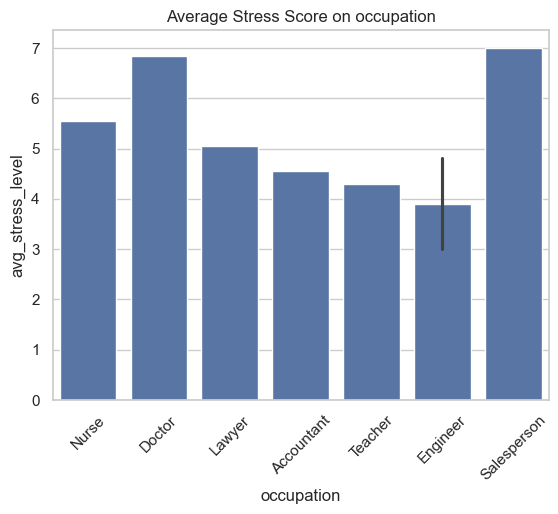

In [56]:
sns.barplot(data=df_kpi4_new, x='occupation', y='avg_stress_level')
plt.xticks(rotation=45)
plt.title("Average Stress Score on occupation")
plt.show()

<Figure size 1000x600 with 0 Axes>

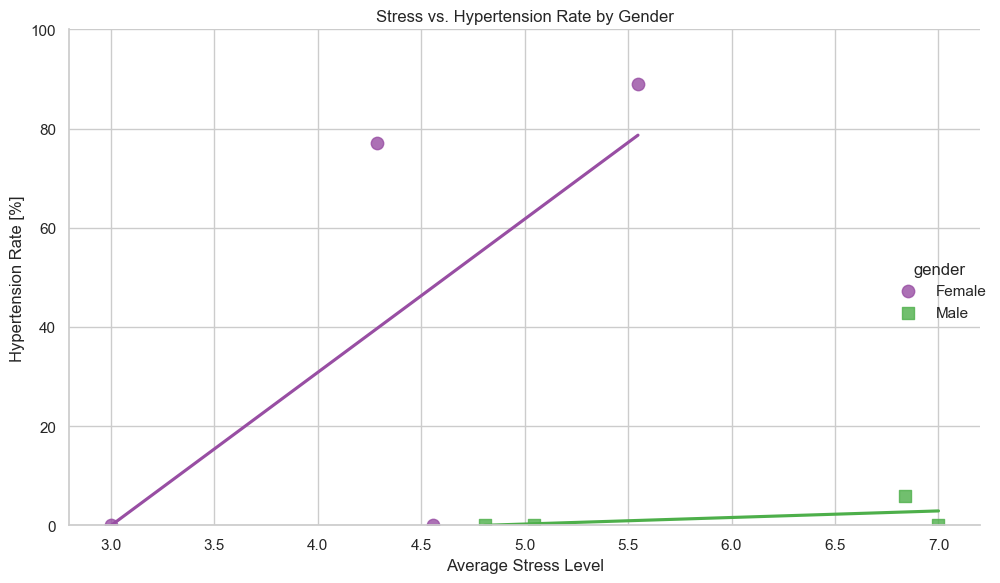

In [57]:
gender_colors = {
    "Female": "#984ea3",  # purple
    "Male": "#4daf4a"     # green
}

plt.figure(figsize=(10, 6))
sns.lmplot(
    x='avg_stress_level',
    y='hypertension_rate_percent',
    hue='gender',
    data=df_kpi4_new,
    palette=gender_colors,
    height=6,
    aspect=1.5,
    markers=['o', 's'],
    scatter_kws={'s': 80},
    ci=None
)

plt.title('Stress vs. Hypertension Rate by Gender')
plt.xlabel('Average Stress Level')
plt.ylabel('Hypertension Rate [%]')
plt.ylim(0, 100)
plt.grid(True)
plt.tight_layout()
plt.show()


In [58]:
# Korrelation für Frauen
female_corr = df_kpi4_new[df_kpi4_new['gender'] == 'Female']['avg_stress_level'].corr(
    df_kpi4_new[df_kpi4_new['gender'] == 'Female']['hypertension_rate_percent']
)

# Korrelation für Männer
male_corr = df_kpi4_new[df_kpi4_new['gender'] == 'Male']['avg_stress_level'].corr(
    df_kpi4_new[df_kpi4_new['gender'] == 'Male']['hypertension_rate_percent']
)

print(f"Korrelation bei Frauen: {female_corr:.2f}")
print(f"Korrelation bei Männern: {male_corr:.2f}")



Korrelation bei Frauen: 0.67
Korrelation bei Männern: 0.53


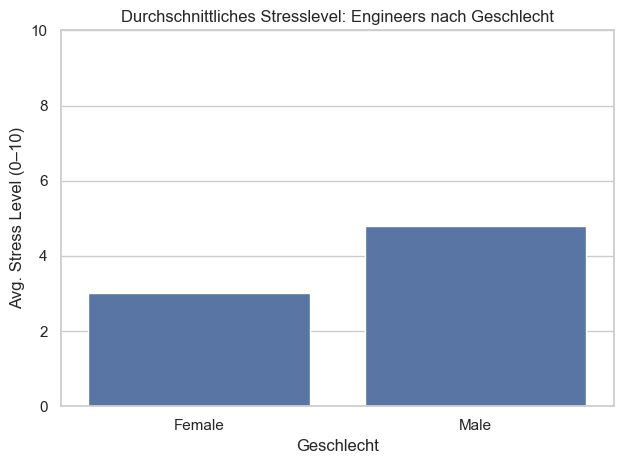

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Nur Engineers filtern
df_engineers = df_kpi4_new[df_kpi4_new['occupation'] == 'Engineer']

# Balkendiagramm: Stresslevel nach Gender
sns.barplot(data=df_engineers, x='gender', y='avg_stress_level')
plt.title('Durchschnittliches Stresslevel: Engineers nach Geschlecht')
plt.ylabel('Avg. Stress Level (0–10)')
plt.xlabel('Geschlecht')
plt.ylim(0, 10)
plt.tight_layout()
plt.show()


In [60]:
df_kpi4_new2 = pd.read_sql(sql=text('SELECT * FROM stress_hypertensionRate_gender'), con=engine)
df_kpi4_new2

,gender,num_persons,avg_stress_level,avg_bp_systolic,avg_bp_diastolic,hypertension_rate
0,Male,189,6.079365,126.941799,83.015873,0.042328
1,Female,185,4.675676,130.200000,86.318919,0.497297


In [61]:
df_kpi4_new2['hypertension_rate_percent'] = df_kpi4_new2['hypertension_rate'] * 100
df_kpi4_new2

,gender,num_persons,avg_stress_level,avg_bp_systolic,avg_bp_diastolic,hypertension_rate,hypertension_rate_percent
0,Male,189,6.079365,126.941799,83.015873,0.042328,4.232804
1,Female,185,4.675676,130.200000,86.318919,0.497297,49.729730


C:\Users\papanikolaou\AppData\Local\Temp\ipykernel_8788\1538237302.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\papanikolaou\AppData\Local\Temp\ipykernel_8788\1538237302.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


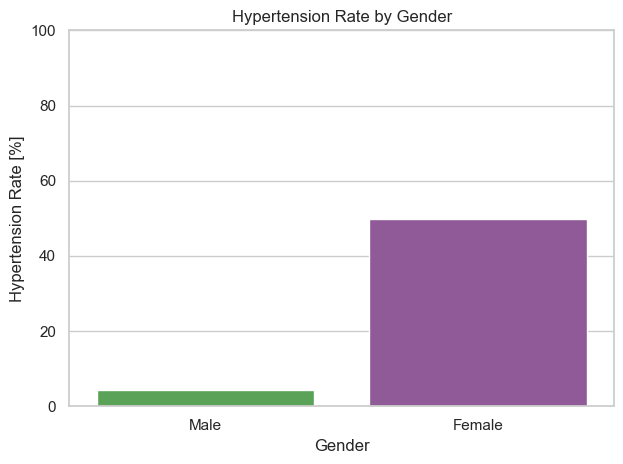

In [62]:
gender_colors = {
    "Female": "#984ea3",  # purple
    "Male": "#4daf4a"     # green
}

sns.barplot(
    x='gender',
    y='hypertension_rate_percent',
    data=df_kpi4_new2,
    palette=gender_colors,
    ci=None
)
plt.title('Hypertension Rate by Gender')
plt.ylabel('Hypertension Rate [%]')
plt.xlabel('Gender')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


In [63]:
df_kpi4_new2 = pd.read_sql(sql=text('SELECT * FROM stress_hypertensionRate_occupation_over_20_persons'), con=engine)
df_kpi4_new2

,occupation,age_group,gender,num_persons,avg_stress_level,avg_bp_systolic,avg_bp_diastolic,hypertension_rate
0,Doctor,Young Adult,Male,65,7.015385,122.076923,80.000000,0.000000
1,Lawyer,Adult,Male,44,5.045455,129.772727,84.863636,0.000000
2,Nurse,Senior,Female,37,3.540541,139.594595,94.648649,0.972973
3,Teacher,Adult,Female,35,4.285714,131.285714,87.142857,0.771429
4,Salesperson,Adult,Male,32,7.000000,130.000000,85.000000,0.000000
5,Nurse,Adult,Female,31,7.806452,138.903226,94.129032,0.935484
6,Engineer,Senior,Female,31,3.000000,125.000000,80.000000,0.000000
7,Accountant,Adult,Female,29,4.068966,115.275862,75.344828,0.000000
8,Engineer,Adult,Male,23,5.173913,127.913043,83.782609,0.000000


In [64]:
df_kpi3 = pd.read_sql(sql=text('SELECT * FROM steps_activity_bmi'), con=engine)
df_kpi3

,bmi_category,bmi_category_order,gender,num_persons,avg_daily_steps,std_daily_steps,avg_physical_activity_level,std_activity_level
0,Normal Weight,2,Female,78,6103.846154,1264.648435,47.692308,16.916378
1,Normal Weight,2,Male,138,7311.594203,1293.671991,63.746377,21.593816
2,Overweight,3,Female,106,7416.037736,1798.736953,67.556604,19.883987
3,Overweight,3,Male,42,5828.571429,514.324428,45.285714,5.802799
4,Obese,4,Female,1,3300.000000,NaN,60.000000,NaN
5,Obese,4,Male,9,3355.555556,292.023591,54.444444,22.699731


In [65]:
df_kpi3_new = pd.read_sql(sql=text('SELECT * FROM steps_activity_bmi_percentage_gender'), con=engine)
df_kpi3_new

,bmi_category,bmi_category_order,gender,num_persons_in_group,percent_of_gender
0,Normal Weight,2,Female,78,42.16
1,Normal Weight,2,Male,138,73.02
2,Overweight,3,Female,106,57.30
3,Overweight,3,Male,42,22.22
4,Obese,4,Female,1,0.54
5,Obese,4,Male,9,4.76


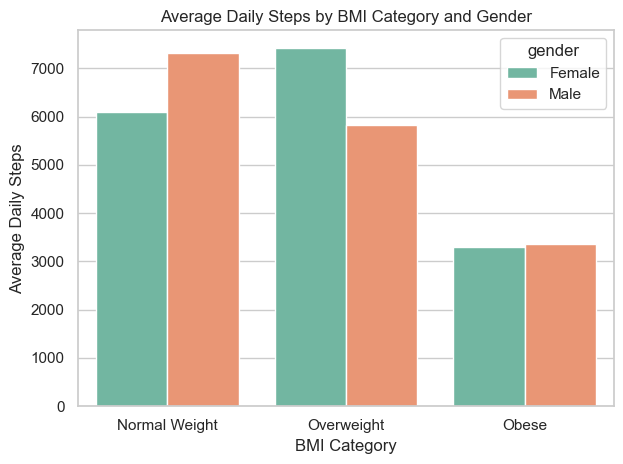

In [66]:
import seaborn as sns

sns.barplot(
    data=df_kpi3,
    x='bmi_category',
    y='avg_daily_steps',
    hue='gender',
    order=['Normal Weight', 'Overweight', 'Obese'],
    palette='Set2'
)

plt.title('Average Daily Steps by BMI Category and Gender')
plt.xlabel('BMI Category')
plt.ylabel('Average Daily Steps')
plt.tight_layout()
plt.show()


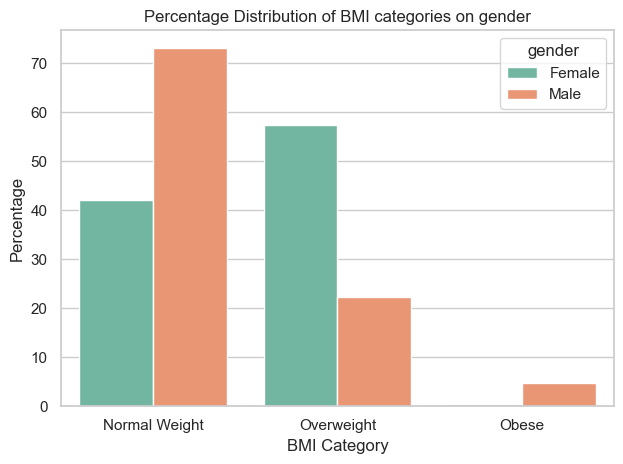

In [67]:
import seaborn as sns


sns.barplot(
    data=df_kpi3_new,
    x='bmi_category',
    y='percent_of_gender',
    hue='gender',
    order=['Normal Weight', 'Overweight', 'Obese'],
    palette='Set2'
)

plt.title('Percentage Distribution of BMI categories on gender')
plt.xlabel('BMI Category')
plt.ylabel('Percentage')
plt.tight_layout()
plt.show()